# Statistical Analysis: Multi-Cuisine Recipe Dataset

This notebook demonstrates how to use the `stat` library to perform real-world statistical analysis on a non-numeric dataset by deriving features and testing hypotheses.

We will explore:
1. **Data Preparation**: Deriving complexity metrics (number of ingredients/steps).
2. **Descriptive Statistics**: Summarizing recipe complexity across cuisines.
3. **Categorical Analysis**: Distribution of cuisines and categories.
4. **Inferential Statistics**: Testing if Indian recipes are significantly more complex than others.
5. **Visualizations**: Understanding the data through plots.

In [2]:
import src.stat as stat
import pandas as pd
import numpy as np

# Load the raw dataset
raw_df = pd.read_csv('assets/Multi_Cuisine_Recipe_Dataset.csv')

# Feature Engineering: Let's create numeric metrics for 'complexity'
raw_df['num_ingredients'] = raw_df['ingredients'].apply(lambda x: len(str(x).split(',')))
raw_df['num_steps'] = raw_df['steps'].apply(lambda x: len(str(x).split('.')))

# Create a Stat object
df = stat.represent(raw_df)
df.show('Recipe Dataset with Complexity Metrics', max_rows=1)

                                      Recipe Dataset with Complexity Metrics                                       
+-----------------------------------------------------------------------------------------------------------------+
|       |                 |        |             |                 |                 | num_ingredient |           |
| Index | name            | area   | category    | ingredients     | steps           | s              | num_steps |
|-------+-----------------+--------+-------------+-----------------+-----------------+----------------+-----------|
|     0 | Hyderabad Soy   | Indian | Main Course | 2 cups Basmati  | To begin making | 41             | 50        |
|       | Biryani  With   |        |             | rice - soaked   | Hyderabad Soy   |                |           |
|       | Vegetables &    |        |             | for 30          | Biryani Recipe  |                |           |
|       | Palak           |        |             | minutes,8 cups  | With Vegetables |                |           |
|       |                 |        |             | Water,Salt - to | & Palak, wash   |                |           |
|       |                 |        |             | taste,1/4 cup   | rice well and   |                |           |
|       |                 |        |             | Soy Chunks      | soak for half   |                |           |
|       |                 |        |             | (Nuggets) -     | an hour.In a    |                |           |
|       |                 |        |             | soaked in hot   | handi, boil     |                |           |
|       |                 |        |             | water for 15    | water, almost   |                |           |
|       |                 |        |             | minutes,1/4 cup | triple the      |                |           |
|       |                 |        |             | Carrots         | quantity of     |                |           |
|       |                 |        |             | (Gajjar) -      | rice or more,   |                |           |
|       |                 |        |             | chopped,1/4 cup | with salt and   |                |           |
|       |                 |        |             | Green beans     | the whole       |                |           |
|       |                 |        |             | (French Beans)  | spices          |                |           |
|       |                 |        |             | - chopped,1/4   | mentioned       |                |           |
|       |                 |        |             | cup Green peas  | above. When the |                |           |
|       |                 |        |             | (Matar),1/4 cup | water comes to  |                |           |
|       |                 |        |             | Cauliflower     | a boil, add the |                |           |
|       |                 |        |             | (gobi) -        | soaked rice and |                |           |
|       |                 |        |             | chopped,1/4 cup | cook till       |                |           |
|       |                 |        |             | Green Bell      | almost done.    |                |           |
|       |                 |        |             | Pepper          | When almost a   |                |           |
|       |                 |        |             | (Capsicum) -    | bite remains in |                |           |
|       |                 |        |             | chopped,3       | the grains,     |                |           |
|       |                 |        |             | Potatoes (Aloo) | drain the rice  |                |           |
|       |                 |        |             | - cubed,2       | in a sieve.     |                |           |
|       |                 |        |             | Tomatoes -      | Keep aside.     |                |           |
|       |                 |        |             | chopp

## 1. Descriptive Summary

How complex is the average recipe in this dataset?

In [3]:
# Get a full descriptive summary of our numeric metrics
df.filter_types('n').summary().show('Global Complexity Summary')

                                             Global Complexity Summary                                             
+-----------------------------------------------------------------------------------------------------------------+
|       |       |      |       |       |       |        | skewn | kurtos |     |      |      |     |      |       |
| Index | mean  | med  | var   | std   | sem   | mad    | ess   | is     | 25% | 75%  | iqr  | min | max  | range |
|-------+-------+------+-------+-------+-------+--------+-------+--------+-----+------+------+-----+------+-------|
| num_… | 14.21 | 13.0 | 43.85 | 6.622 | 0.266 | 5.4483 | 0.612 | 0.0234 | 9.0 | 19.0 | 10.0 | 2.0 | 41.0 | 39.0  |
|       | 93548 |      | 83350 | 56257 | 18326 | 870967 | 57886 | 434240 |     |      |      |     |      |       |
|       | 38709 |      | 67637 | 55924 | 39295 | 74193  | 48869 | 959977 |     |      |      |     |      |       |
|       | 677   |      | 89    | 64    | 4156  |        | 02    | 6      |     |      |      |     |      |       |
| num_… | 15.30 | 14.0 | 58.70 | 7.662 | 0.307 | 5.9887 | 0.929 | 1.0854 | 9.0 | 19.0 | 10.0 | 1.0 | 50.0 | 49.0  |
|       | 48387 |      | 86862 | 15937 | 96818 | 096774 | 31175 | 995553 |     |      |      |     |      |       |
|       | 09677 |      | 64308 | 34604 | 71625 | 193544 | 28265 | 619826 |     |      |      |     |      |       |
|       | 42    |      | 014   | 62    | 9194  |        | 425   |        |     |      |      |     |      |       |
+-----------------------------------------------------------------------------------------------------------------+

## 2. Cuisine Analysis

Which cuisines are most represented, and do they differ in complexity?

In [4]:
# Top 10 most frequent cuisines
df.frequencies('area').show('Top Cuisines', max_rows=10)

# Average complexity by cuisine (Top 5)
df.groupby(by='area', operation='mean').show('Average Metrics by Cuisine', max_rows=5)

     Top Cuisines     
+--------------------+
|      Index | count |
|------------+-------|
|     Indian | 200   |
|   American | 77    |
|    British | 59    |
|    Spanish | 48    |
|    Turkish | 30    |
|     French | 28    |
|    Chinese | 27    |
| Vietnamese | 27    |
|     Polish | 27    |
|   Jamaican | 27    |
|        ... | ...   |
+--------------------+

              Average Metrics by Cuisine              
+----------------------------------------------------+
|    Index | num_ingredients    | num_steps          |
|----------+--------------------+--------------------|
| American | 9.415584415584416  | 9.987012987012987  |
|  British | 10.64406779661017  | 17.305084745762713 |
| Canadian | 10.272727272727273 | 14.181818181818182 |
|  Chinese | 13.148148148148149 | 15.518518518518519 |
|   French | 10.821428571428571 | 15.928571428571429 |
|      ... | ...                | ...                |
+----------------------------------------------------+

## 3. Visualizing Complexity

Let's visualize the distribution of ingredients and the relationship between steps and ingredients.

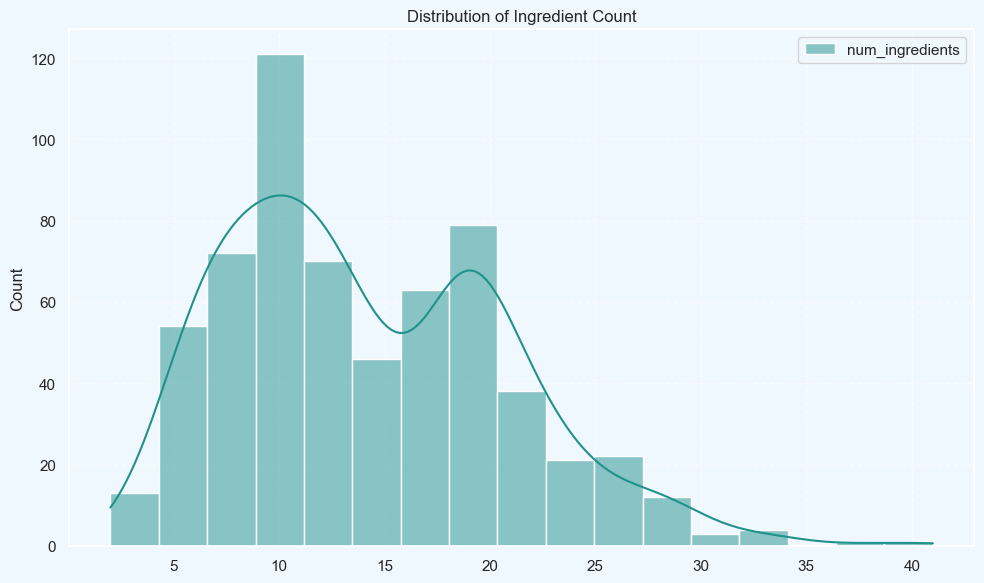

C:\Users\aarin\PycharmProjects\Stat\src\stat\graphs\plotter.py:69: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax, **kwargs)


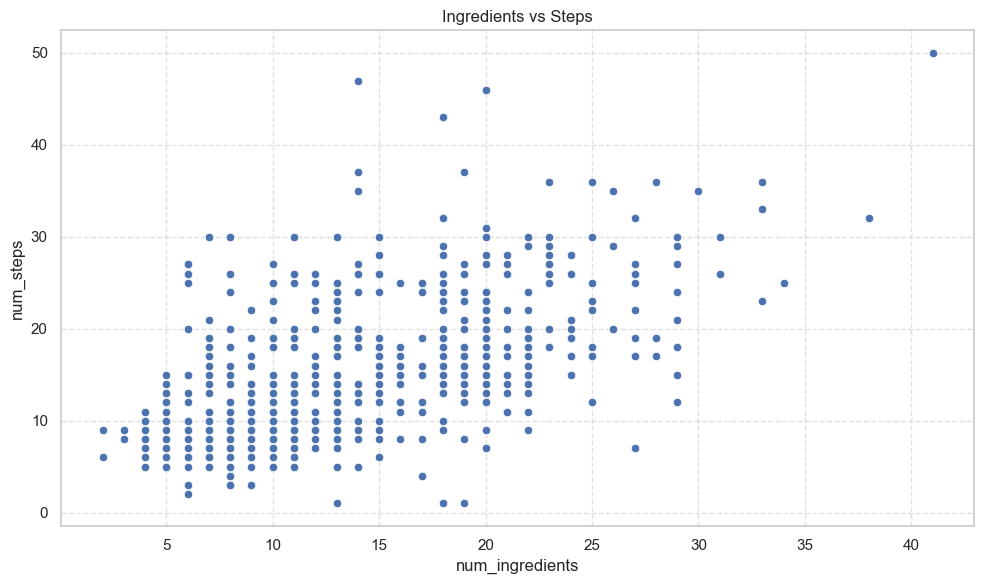

In [5]:
# Distribution of number of ingredients
df.plot(columns='num_ingredients', kind='hist', title='Distribution of Ingredient Count', theme='ocean')

# Relationship between ingredients and steps
df.plot(columns=['num_ingredients', 'num_steps'], kind='scatter', title='Ingredients vs Steps')

## 4. Inferential Statistics: The "Indian Cuisine Complexity" Test

Indian recipes often seem to have many ingredients. Let's test if the mean number of ingredients in Indian recipes is significantly higher than the mean of American recipes.

In [6]:
# Filter data for the two groups
indian_recipes = stat.represent(raw_df[raw_df['area'] == 'Indian'])
american_recipes = stat.represent(raw_df[raw_df['area'] == 'American'])

print(f"Indian Mean Ingredients: {indian_recipes.mean(series='num_ingredients'):.2f}")
print(f"American Mean Ingredients: {american_recipes.mean(series='num_ingredients'):.2f}")

# Perform Independent Two-Sample T-Test
results = indian_recipes.t_test(other=american_recipes, series='num_ingredients', other_series='num_ingredients')

print("\nT-Test Results:")
for key, val in results.items():
    print(f"{key}: {val}")

if results['p_value'] < 0.05:
    print("\nConclusion: The difference is statistically significant (p < 0.05).")
else:
    print("\nConclusion: No statistically significant difference found (p >= 0.05).")

Indian Mean Ingredients: 21.94
American Mean Ingredients: 9.42

T-Test Results:
statistic: 23.56697896556553
p_value: 5.949807297527182e-68
df: 275
method: Independent Two-sample T-test

Conclusion: The difference is statistically significant (p < 0.05).


## 5. Summary Statistics by Category

Finally, let's see which category (Main Course, Dessert, etc.) is the most complex on average.

In [7]:
df.groupby(by='category', operation='mean').show('Complexity by Category')

                       Complexity by Category                       
+------------------------------------------------------------------+
|                  Index | num_ingredients    | num_steps          |
|------------------------+--------------------+--------------------|
|              Appetizer | 21.75              | 18.833333333333332 |
|                   Beef | 12.78048780487805  | 15.073170731707316 |
|              Breakfast | 7.454545454545454  | 14.909090909090908 |
|                Chicken | 12.311111111111112 | 13.444444444444445 |
|                Dessert | 10.766355140186915 | 14.94392523364486  |
|                 Dinner | 22.17391304347826  | 19.130434782608695 |
|                   Goat | 14.0               | 18.0               |
|       Indian Breakfast | 19.5               | 18.5               |
|                   Lamb | 11.0625            | 12.0               |
|                  Lunch | 22.0625            | 18.84375           |
|            Main Course | 23.14814814814815  | 23.11111111111111  |
|          Miscellaneous | 9.0                | 14.0               |
|           One Pot Dish | 18.0               | 15.0               |
|                  Pasta | 9.75               | 12.875             |
|                   Pork | 11.275862068965518 | 12.724137931034482 |
|                Seafood | 11.092592592592593 | 12.018518518518519 |
|                   Side | 8.043478260869565  | 12.478260869565217 |
|              Side Dish | 20.952380952380953 | 20.571428571428573 |
|                  Snack | 19.923076923076923 | 20.46153846153846  |
| South Indian Breakfast | 26.75              | 24.5               |
|                    ... | ...                | ...                |
+------------------------------------------------------------------+